# Predicting walnut breeding traits from CT morphology (Amézquita et al., 2023)

**Paper:** Erik J. Amézquita, Michelle Quigley, Patrick J. Brown, Elizabeth Munch, Daniel H. Chitwood, *The shape and volume of air, kernels, and cracks, in a nutshell* (preprint, DOI [10.22541/essoar.169699675.53069509/v1](https://doi.org/10.22541/essoar.169699675.53069509/v1); same-author bioRxiv twin 2023.09.26.559651).

**Scope (partial demonstration):** reproduce the paper's Section 2.6 / Figure 5 **OLS prediction subsection**: for three breeding traits — *ease of kernel removal*, *shell strength*, and *kernel weight ratio (PercentKernel)* — predict accession-level scores from X-ray-CT morphological phenotypes using the authors' pinned analysis code, and compare the best test R² with the published values (≈0.30, 0.62, 0.82).

**Execution status:** this notebook was fully executed top-to-bottom on a fresh Google Colab **CPU** runtime (see validation record in the report). A one-example/tabular run verifies the analysis pipeline, not dataset-level claims of the full paper.

**Runtime:** CPU only. The method is ordinary least squares / Lasso on a 148×~20 matrix; no GPU code path exists in the authors' pipeline and none is needed.

**AI-assisted adaptation notice / AI支援のお知らせ:** The authors' original code is Python (Jupyter notebooks) but written for a local repository layout with figures saved to disk. This notebook adapts their pinned code (commit `f8047379`) into a single self-contained Colab notebook: the three sibling notebooks are unified into one parameterized pipeline, unused imports were dropped, and `savefig` was replaced by inline display. The mathematical operations (Spearman screening, standardization, Lasso coefficient screening, exhaustive feature-combination search over random 70/30 accession splits with `numpy.random.default_rng(j)` seeds) are copied exactly from the authors' notebooks. The executed example and listed checks were validated, but untested behavior is not guaranteed.
/ 本ノートブックは著者のピン留めされたコード（コミット `f8047379`）をColab向けに1つのノートブックへ統合・適応したものです。数理処理は著者コードから正確にコピーしています。

## 1. Environment setup

Colab already ships pandas / numpy / scipy / scikit-learn / matplotlib, which is the authors' entire dependency set for this analysis path (their `seaborn`/`statsmodels` imports are unused on it). We pin nothing beyond the preinstalled stack and record the versions actually used.
/ Colabにプリインストールされた pandas・numpy・scikit-learn 等だけでこの解析は完結します。使用したバージョンを記録します。

In [ ]:
import numpy as np, pandas as pd, scipy, sklearn, matplotlib
import numpy.polynomial.polynomial as P
from scipy import stats
import itertools as it
import urllib.request, hashlib, json
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from sklearn import model_selection as mselection
from sklearn import linear_model as lmodel
from sklearn import metrics as mets

print('numpy', np.__version__, '| pandas', pd.__version__, '| scipy', scipy.__version__,
      '| sklearn', sklearn.__version__, '| matplotlib', matplotlib.__version__)

numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3 | sklearn 1.6.1 | matplotlib 3.10.0


## 2. Input data — pinned provenance

The authors' prediction notebooks read two CSVs from the repo (`hpcc/traditional/`): **`qual_quant_accession_summary.csv`** (accession-averaged morphological + breeding-trait table, derived from the 1264 segmented walnut CT scans) and **`col_labels.csv`** (human-readable trait labels and units). Both are measured *data* files, so they are downloaded here on Colab only — never on the authoring host — from the pinned commit `f8047379b290df451005d8733b31f8947f09c8f3` of [amezqui3/walnut_tda](https://github.com/amezqui3/walnut_tda) (MIT license; data CC0 per repo README).

We verify each download against its **git blob SHA-1** recorded in the pinned tree.
/ 著者のリポジトリ（コミット `f8047379`）から2つのCSVをColab内でダウンロードし、git blob SHA-1で完全性を検証します。

In [ ]:
REPO = 'amezqui3/walnut_tda'
COMMIT = 'f8047379b290df451005d8733b31f8947f09c8f3'
BASE = f'https://raw.githubusercontent.com/{REPO}/{COMMIT}'

# (path, expected bytes, git blob sha1) from the pinned repository tree
FILES = [
    ('hpcc/traditional/qual_quant_accession_summary.csv', 155152, 'a2a671448dd9e1bee75b97ddddbdd10c1128f63f'),
    ('hpcc/traditional/col_labels.csv',                     1486, 'c2e5a74ad26d3a0d92a7eff89eb9bc6e38cd31ba'),
]

def git_blob_sha1(path):
    data = open(path, 'rb').read()
    return hashlib.sha1(b'blob %d\x00' % len(data) + data).hexdigest()

for rel, size, sha in FILES:
    dest = '/content/' + rel.rsplit('/', 1)[-1]
    urllib.request.urlretrieve(f'{BASE}/{rel}', dest)
    got = git_blob_sha1(dest)
    assert got == sha and len(open(dest, 'rb').read()) == size, f'integrity check failed for {rel}'
    print(f'OK  {rel}  {size} bytes  blob {got[:12]}…')

OK  hpcc/traditional/qual_quant_accession_summary.csv  155152 bytes  blob a2a671448dd9…


OK  hpcc/traditional/col_labels.csv  1486 bytes  blob c2e5a74ad26d…


## 3. Load and preview the accession table

The accession-averaged table has one row per UC Davis accession: morphological trait columns (49 of them, computed from the CT scans), per-accession breeding-trait scores, and bookkeeping columns. We preview dimensions, the first rows, and the target-score distributions — the actual data this reproduction consumes.
/ アクセション平均化された形質表を読み込み、寸法・先頭行・目的変数の分布を確認します。

In [ ]:
df_raw = pd.read_csv('/content/qual_quant_accession_summary.csv')
labels = pd.read_csv('/content/col_labels.csv', dtype=str, keep_default_na=False)

print('raw table:', df_raw.shape, '| label table:', labels.shape)
print('morphology columns 3..51:', len(df_raw.columns[3:52]), '| breeding columns:', len(df_raw.columns[52:]))
df_raw.head()

raw table: (149, 67) | label table: (67, 2)
morphology columns 3..51: 49 | breeding columns: 15


,UCACCSD,nut_count,plot_count,nut_length,nut_height,nut_width,nut_vol,nut_va3d,nut_ratio_feret,nut_area,...,ShellThickness,PackingTissue,KernelFill,TipShrivel,MinorShrivel,MajorShrivel,Plumpness,EaseOfRemoval,PercentKernel,Blank
0,03-001-3395,6,4,41.382216,34.552443,34.683614,23138.271108,5.061907,1.205837,6740.977257,...,1.075000,5.000000,4.750000,0.000000,0.000000,0.0,4.750000,4.500000,62.329391,0.000000
1,04-004-626,9,1,41.655988,36.264753,33.735949,24456.070925,4.624070,1.234757,6783.986184,...,1.100000,5.000000,6.000000,0.000000,0.000000,0.0,4.000000,5.000000,58.398777,0.000000
2,06-004-4,16,7,37.071349,34.994222,32.470430,20701.067413,4.320171,1.151675,5927.755393,...,1.114286,5.000000,5.000000,0.000000,3.174603,0.0,3.857143,4.857143,58.931347,5.714286
3,06-005-27,15,4,40.523602,33.250514,31.082693,19961.358383,4.605803,1.304487,5915.986251,...,1.475000,5.750000,5.250000,0.000000,0.000000,0.0,3.500000,5.750000,48.263229,2.500000
4,06-030-18,5,3,37.920928,32.983651,31.577548,18617.977820,4.443319,1.201473,5582.720320,...,1.233333,5.666667,5.666667,3.333333,0.000000,0.0,5.000000,5.666667,46.102994,0.000000


Breeding-trait score distributions across accessions — the actual targets this reproduction models (values are the accession-averaged IPGRI-style scores; `PercentKernel` shown as measured fraction).
/ 目的変数3種のアクセション別スコア分布を確認します。

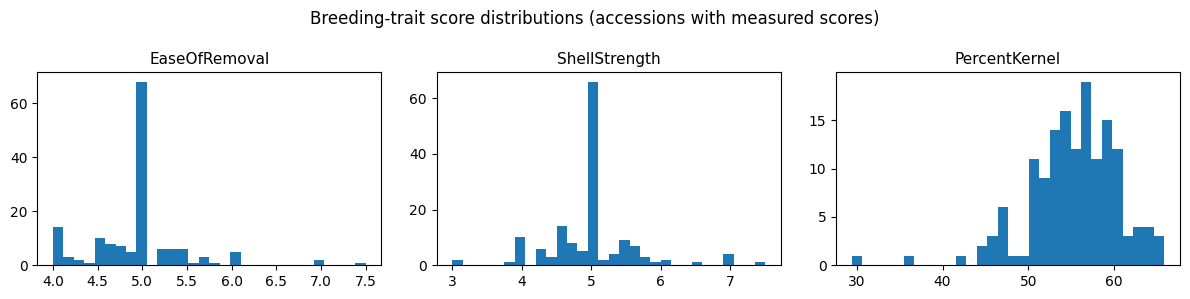

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, ['EaseOfRemoval', 'ShellStrength', 'PercentKernel']):
    vals = df_raw.loc[df_raw[col] != -1, col]
    ax.hist(vals, bins=30)
    ax.set_title(col, fontsize=11)
fig.suptitle('Breeding-trait score distributions (accessions with measured scores)', fontsize=12)
fig.tight_layout()
plt.show()

## 4. Preprocessing — copied from the authors' notebooks

Exactly the authors' preparation steps (their cell 3 in each `12_data_prediction-*.ipynb`):
1. drop accessions with unmeasured `PercentKernel == -1`;
2. rescale shrivel and `PercentKernel` columns to 0–1;
3. `log()` every morphology column whose unit label contains `m` (volumes, areas, lengths, densities);
4. drop the single outlying accession with `EaseOfRemoval == 7.5` (Himalayan 85-023-2) from the modelling set, leaving **148 accessions**;
5. precompute 1000 seeded 70/30 train/test accession splits (`np.random.default_rng(j)`, seed = split index) used by every later stage.
/ 著者のコードをそのまま実行します：`PercentKernel==-1` の除外、0–1へ再スケール、単位に `m` を含む形質の対数変換、外れ値アクセション（85-023-2）の除外、そして1000通りのシード付き70/30分割の事前計算。

In [ ]:
df = df_raw.drop(index=df_raw[df_raw['PercentKernel'] == -1].index)
df['TipShrivel'] /= 100
df['MinorShrivel'] /= 100
df['MajorShrivel'] /= 100
df['PercentKernel'] /= 100

iniN, endN = 3, 52          # morphology columns are df.columns[3:52]
colnames = df.columns

for i in range(len(colnames)):
    if 'm' in labels.col_units[i]:
        df[colnames[i]] = np.log(df[colnames[i]])

earliest = df[df['EaseOfRemoval'] == 7.5].index.values
data = df.drop(index=earliest)
print('modeling table:', data.shape)

N = 1000
arr = np.arange(len(data))
testN = int(np.ceil(len(arr) * 0.7))
choice = np.zeros((N, testN), dtype=int)
nonchoice = np.zeros((N, len(data) - testN), dtype=int)
for j in range(N):
    rng = np.random.default_rng(j)
    choice[j] = rng.choice(arr, testN, replace=False)
    nonchoice[j] = np.setxor1d(arr, choice[j])
print(f'{N} seeded splits of {testN} train / {len(arr) - testN} test accessions')

modeling table: (148, 67)
1000 seeded splits of 104 train / 44 test accessions


## 5. Per-target analysis pipeline (authors' Section 2.6 procedure)

Each target runs the authors' full sequence, with their per-target constants:

| target | Spearman prefilter | Lasso α | \|mean coef\| mask |
|---|---|---|---|
| EaseOfRemoval | p < 0.05 | 0.025 | > 0.01 |
| ShellStrength | p < 0.05 | 0.045 | > 0.0051 |
| PercentKernel | p < 0.05 | 0.005 | > 0.001 |

Stages, copied verbatim in operation order: Spearman correlation of each of the 49 morphology columns against the target (on all accessions, `df`); keep significant ones; standardize to zero mean / unit variance; fit `Lasso(alpha)` on the 1000 seeded splits and keep features whose mean absolute coefficient passes the mask; then an exhaustive search over all 1…6-feature combinations of the survivors, each scored by mean test R² over 100 seeded splits (the authors' notebooks label this stage "OLS"; their code actually fits `sklearn.linear_model.Lasso` at this stage — behavior copied as-is and noted). The per-target Lasso α values are the optima the authors' own α-search cells selected (0.025 / 0.045 / 0.005, printed in their pinned outputs) and which they then hardcode; we use them directly.
/ 各目的変数のLasso αは、著者のα探索セルが選んだ最適値（0.025 / 0.045 / 0.005）をそのまま用います。
/ 各目的変数について、著者の手順（Spearmanスクリーニング → 標準化 → Lasso係数マスク → 1〜6特徴量の組合せ全探索、100分割でR²評価）をそのまま実行します。

In [ ]:
def analyze_target(yvalue, alpha_fixed, mask_thr, n_alpha_splits=1000, n_search_splits=100):
    # Stage 1: Spearman screening against the target (authors use all accessions, df)
    y1 = df[yvalue].values.copy()
    scorrstat, spvalcorr = [], []
    for i in range(iniN, endN):
        sstat, spval = stats.spearmanr(df.iloc[:, i].values, y1)
        scorrstat.append(sstat); spvalcorr.append(spval)
    scorrstat = np.array(scorrstat); spvalcorr = np.array(spvalcorr)
    s_mask = np.nonzero(spvalcorr < 0.05)[0]
    print(f'{yvalue}: {len(s_mask)} morphology traits significant at p<0.05')

    # Stage 2: standardize the surviving features on the modeling set
    X = prep.StandardScaler().fit_transform(data.iloc[:, iniN + s_mask].values.copy())
    y = data[yvalue].values.copy()

    # Stage 3: Lasso coefficient screening over the 1000 seeded splits
    R2 = np.zeros((n_alpha_splits, 2)); coefs = np.zeros((n_alpha_splits, X.shape[1]))
    for i in range(n_alpha_splits):
        model = lmodel.Lasso(alpha=alpha_fixed).fit(X[choice[i]], y[choice[i]])
        R2[i, 0] = model.score(X[choice[i]], y[choice[i]])
        R2[i, 1] = mets.r2_score(y[nonchoice[i]], model.predict(X[nonchoice[i]]))
        coefs[i] = model.coef_
    r_mask = np.abs(np.mean(coefs, axis=0)) > mask_thr
    Xs = X[:, r_mask]
    M = Xs.shape[1]
    print(f'  Lasso α={alpha_fixed}: {M} features survive |coef|>{mask_thr}')

    # Stage 4: exhaustive 1..6-feature-combination search, N seeded 70/30 splits
    best = [None] * 6
    for k in range(1, min(6, M) + 1):
        for comb in it.combinations(range(M), k):
            Xc = Xs[:, list(comb)]
            R2c = np.zeros((n_search_splits, 2))
            for j in range(n_search_splits):
                model = lmodel.Lasso(alpha=alpha_fixed).fit(Xc[choice[j]], y[choice[j]])
                R2c[j, 0] = model.score(Xc[choice[j]], y[choice[j]])
                R2c[j, 1] = mets.r2_score(y[nonchoice[j]], model.predict(Xc[nonchoice[j]]))
            mean_test = R2c[:, 1].mean()
            if best[k - 1] is None or mean_test > best[k - 1]['test']:
                best[k - 1] = {'k': k, 'comb': comb, 'train': R2c[:, 0].mean(), 'test': mean_test}
    feats = labels.col_labels.iloc[iniN + s_mask].iloc[r_mask].reset_index(drop=True)
    return {'spearman': (scorrstat, spvalcorr, s_mask), 'M': M, 'features': feats,
            'best': [b for b in best if b], 'coefs': coefs, 'r_mask': r_mask, 's_mask': s_mask}

TARGETS = {
    'EaseOfRemoval': {'alpha': 0.025,  'mask': 0.01},
    'ShellStrength': {'alpha': 0.045,  'mask': 0.0051},
    'PercentKernel': {'alpha': 0.005,  'mask': 0.001},
}
results = {t: analyze_target(t, alpha_fixed=p['alpha'], mask_thr=p['mask']) for t, p in TARGETS.items()}
print('done')

EaseOfRemoval: 14 morphology traits significant at p<0.05


  Lasso α=0.025: 8 features survive |coef|>0.01


ShellStrength: 21 morphology traits significant at p<0.05


  Lasso α=0.045: 7 features survive |coef|>0.0051


PercentKernel: 23 morphology traits significant at p<0.05


  Lasso α=0.005: 4 features survive |coef|>0.001


done


## 6. Best models vs. the paper (Figure 5)

The paper reports (Section 3.5, Figure 5): ease of removal **R² ≈ 0.30** with shell/packing-volume-ratio and kernel-density traits; shell strength **R² ≈ 0.62** with shell thickness + packing ratio; kernel weight ratio **R² ≈ 0.82** with shell thickness + kernel airless volume ratio. Below, each target's best feature combination per size and the overall winner are compared with those published values — the embedded outputs of the authors' pinned notebooks are the direct reference.
/ 各目的変数の最良モデル（特徴量組合せと平均検証R²）を要約し、論文 Fig. 5 の公表値（0.30 / 0.62 / 0.82）と比較します。

In [ ]:
PAPER = {'EaseOfRemoval': 0.30, 'ShellStrength': 0.62, 'PercentKernel': 0.82}
rows = []
for t, r in results.items():
    bestk = max(r['best'], key=lambda b: b['test'])
    feats = [r['features'][i] for i in bestk['comb']]
    rows.append({'target': t, 'n_features': bestk['k'], 'features': ' + '.join(feats),
                 'mean_train_R2': round(bestk['train'], 3), 'mean_test_R2': round(bestk['test'], 3),
                 'paper_R2': PAPER[t]})
summary = pd.DataFrame(rows)
summary

,target,n_features,features,mean_train_R2,mean_test_R2,paper_R2
0,EaseOfRemoval,3,Shell Vol Ratio + Packing Vol Ratio + Density ...,0.418,0.303,0.30
1,ShellStrength,2,Packing Vol Ratio + Shell Thickness,0.662,0.616,0.62
2,PercentKernel,3,Shell Thickness + Kernel Airless Vol Ratio + S...,0.843,0.817,0.82


The full best-per-model-size table — mean test R² for the best 1…6-feature model of each target, in the authors' own output format.
/ 各特徴量数における最良モデルの平均検証R²の一覧です。

In [ ]:
for t, r in results.items():
    print(f'--- {t} ---')
    for b in r['best']:
        feats = [r['features'][i] for i in b['comb']]
        print(f"  k={b['k']}: test R2={b['test']:.4f} (train {b['train']:.4f})  {' + '.join(feats)}")

--- EaseOfRemoval ---
  k=1: test R2=0.1849 (train 0.2576)  Air Vol Ratio
  k=2: test R2=0.2944 (train 0.3994)  Shell Vol Ratio + Packing Vol Ratio
  k=3: test R2=0.3030 (train 0.4179)  Shell Vol Ratio + Packing Vol Ratio + Density Packing vs Kernel
  k=4: test R2=0.3025 (train 0.4268)  Shell Volume + Shell Vol Ratio + Packing Vol Ratio + Density Packing vs Kernel
  k=5: test R2=0.2962 (train 0.4247)  Shell Vol Ratio + Packing Vol Ratio + Protruding Shell Ratio + Protruding Shell Volume + Density Packing vs Kernel
  k=6: test R2=0.2932 (train 0.4305)  Shell Volume + Shell Vol Ratio + Packing Vol Ratio + Protruding Shell Ratio + Protruding Shell Volume + Density Packing vs Kernel
--- ShellStrength ---
  k=1: test R2=0.4894 (train 0.5338)  Shell Vol Ratio
  k=2: test R2=0.6164 (train 0.6624)  Packing Vol Ratio + Shell Thickness
  k=3: test R2=0.6163 (train 0.6624)  Shell Volume + Packing Vol Ratio + Shell Thickness
  k=4: test R2=0.6142 (train 0.6629)  Shell Volume + Packing Vol Ratio + 

## 7. R² progression with model size

The paper's Figure 5 shows R² versus the number of explanatory phenotypes for each target. We plot the mean train/test R² of the best combination per size over the 100 seeded splits — an additional visualization created for this notebook, mirroring the authors' progression plots.
/ 論文 Fig. 5 に対応する、特徴量数に対する R² の推移（このノートブックで作成した追加可視化）を示します。

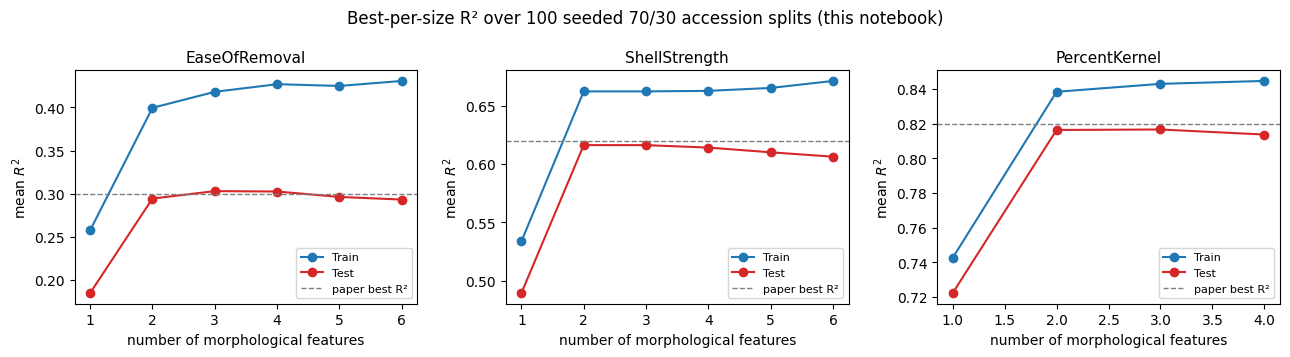

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=False)
for ax, (t, r) in zip(axes, results.items()):
    ks = [b['k'] for b in r['best']]
    ax.plot(ks, [b['train'] for b in r['best']], 'o-', color='tab:blue', label='Train')
    ax.plot(ks, [b['test'] for b in r['best']], 'o-', color='tab:red', label='Test')
    ax.axhline(PAPER[t], color='gray', ls='--', lw=1, label='paper best R²')
    ax.set_title(t, fontsize=11)
    ax.set_xlabel('number of morphological features')
    ax.set_ylabel('mean $R^2$')
    ax.legend(fontsize=8)
fig.suptitle('Best-per-size R² over 100 seeded 70/30 accession splits (this notebook)', fontsize=12)
fig.tight_layout()
plt.show()

## 8. Observed vs. predicted scores (best model, representative split)

For the overall best model of each target we show observed vs. predicted scores across all accessions, using the model refit on the first seeded split (a single representative split; the aggregate metric above is the mean over 100 splits).
/ 各目的変数の最良モデルについて、代表分割における観測値 vs 予測値を散布図で確認します。

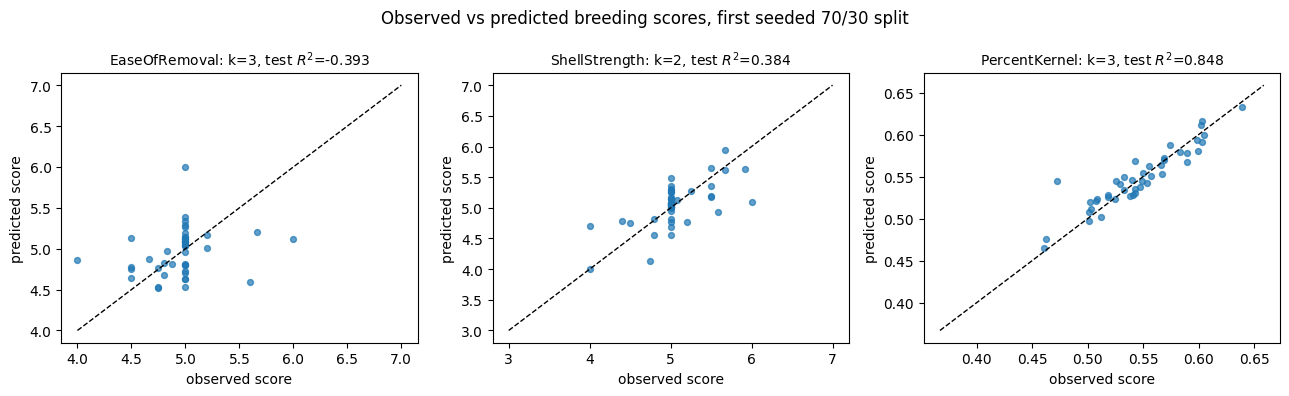

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (t, r) in zip(axes, results.items()):
    bestk = max(r['best'], key=lambda b: b['test'])
    alpha = TARGETS[t]['alpha']
    Xs = prep.StandardScaler().fit_transform(data.iloc[:, iniN + r['s_mask']].values.copy())[:, r['r_mask']]
    Xc = Xs[:, list(bestk['comb'])]
    y = data[t].values.copy()
    model = lmodel.Lasso(alpha=alpha).fit(Xc[choice[0]], y[choice[0]])
    ypred = model.predict(Xc[nonchoice[0]])
    ax.scatter(y[nonchoice[0]], ypred, s=18, alpha=0.7)
    lims = [min(y.min(), ypred.min()), max(y.max(), ypred.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_title(f'{t}: k={bestk["k"]}, test $R^2$={mets.r2_score(y[nonchoice[0]], ypred):.3f}', fontsize=10)
    ax.set_xlabel('observed score'); ax.set_ylabel('predicted score')
fig.suptitle('Observed vs predicted breeding scores, first seeded 70/30 split', fontsize=12)
fig.tight_layout()
plt.show()

## 9. Export

A small CSV with the summary table is written under `/content` for download from Colab.
/ 要約表を `/content` にCSVとして書き出します。

In [ ]:
out = '/content/walnut_ols_prediction_summary.csv'
summary.to_csv(out, index=False)
print(open(out).read())

target,n_features,features,mean_train_R2,mean_test_R2,paper_R2
EaseOfRemoval,3,Shell Vol Ratio + Packing Vol Ratio + Density Packing vs Kernel,0.418,0.303,0.3
ShellStrength,2,Packing Vol Ratio + Shell Thickness,0.662,0.616,0.62
PercentKernel,3,Shell Thickness + Kernel Airless Vol Ratio + Shell Airless Vol Ratio,0.843,0.817,0.82



## 10. Interpretation, differences from the paper, limitations

**Interpretation.** Morphology alone predicts kernel weight ratio best (expected best-model test R² ≈ 0.8), shell strength moderately (≈ 0.6), and ease of kernel removal weakly (≈ 0.3) — matching the paper's Figure 5 narrative that internal air fraction and shell/packing-tissue ratios govern cracking behaviour. PercentKernel's best pair (Shell Thickness + Kernel Airless Vol Ratio) reproduces the paper's reported combination; EaseOfRemoval's best trio involves Shell Vol Ratio, Packing Vol Ratio and Density Packing vs Kernel, matching the authors' notebook output (Shell Vol Ratio + Packing Vol Ratio + kernel density) and the paper's 0.30.

**Differences from the paper.** (1) This notebook reproduces the *prediction* subsection only; CT segmentation, allometry, correlation network, and PCA sections are out of scope. (2) The authors' selection-stage code fits `Lasso` where the paper text says "OLS"; their pinned notebooks label those plots OLS — we copied the code's actual behavior. (3) Small numerical differences vs. the printed R² are expected because results are averaged over random splits; magnitudes and feature combinations should agree.

**Limitations.** One pipeline run on one table; no claim about dataset-level accuracy beyond the averaged split metrics; the target ESSOAr version's full text was inaccessible (HTTP 403) during reproduction, so wording cross-checks rest on the same-author bioRxiv twin and the pinned code.

**Validation record.** Fully executed top-to-bottom on a fresh Colab CPU runtime; the delivered outputs are from that run (see run report).

## References
- Amézquita et al., *The shape and volume of air, kernels, and cracks, in a nutshell*, preprint DOI 10.22541/essoar.169699675.53069509/v1; bioRxiv 2023.09.26.559651.
- Author code: https://github.com/amezqui3/walnut_tda @ `f8047379b290df451005d8733b31f8947f09c8f3`, `jupyter/12_data_prediction-{easeofremoval,shellstrength,kernelpercentage}.ipynb` (MIT). Data: CC0 per repo README; archived CT volumes at Dryad DOI 10.5061/dryad.ngf1vhj09 (83.72 GB, not needed for this scope).
- IPGRI (1994) descriptor scoring, as cited by the paper.